# Experiment: Supplement: c_BE Velocity Calibration

Objective:
- Step 1: measure the deterministic speed law $v_\theta(c_{BE})$ under a sustained constant bump-to-edge drive.
- Step 2: use the measured $v_\theta(c_{BE})$ together with the code-level mapping $x(\theta)$ to derive a numerical $c_{BE}(\theta)$ that yields a desired constant latent-space speed $v_x$.

Success criteria:
- The notebook produces a clean empirical plot of $v_\theta$ versus $c_{BE}$ around the small-signal regime.
- The notebook produces a numerical $c_{BE}(\theta)$ curve for a user-chosen target $v_x$.
- The notebook stays close to the validated Figure 2 baseline configuration in `figures_code/main/fig2_micro_dyn_scheme.ipynb`.


In [6]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

%config InlineBackend.figure_format = 'retina'

def find_repo_root() -> Path:
    candidates = []
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents, (cwd / '..').resolve(), (cwd / '../..').resolve()])
    seen = set()
    for candidate in candidates:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / 'CANN_DDM_model_rate_based.py').exists():
            return candidate
    raise RuntimeError('Could not locate repository root from the current notebook session.')

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from CANN_DDM_model_rate_based import CANN_DDM_model
from rate_model_core.default_params import build_stable_default_params

SEED = 4
np.random.seed(SEED)
REPO_ROOT


PosixPath('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model')

In [8]:
def build_baseline_params(*, c_be: float = 0.0, x0: float = 0.5) -> dict:
    params = build_stable_default_params()
    params['bump_pop']['c_BE'] = float(c_be)
    params['bump_pop']['noise_scale_bump'] = 0.0
    params['edge_pop']['noise_scale_edge'] = 0.0
    params['decision_space_params']['x0'] = float(x0)
    return params


class ConstantDriveIBEModel(CANN_DDM_model):
    """Use the existing c_BE scalar as a sustained post-onset I_BE amplitude."""

    def get_current_I_BE(self, cue_R, cue_L, r_B, c_BE):
        filtered_r_B = self.W_BE @ r_B
        return c_BE * filtered_r_B


def make_model(*, c_be: float, x0: float = 0.5) -> ConstantDriveIBEModel:
    model = ConstantDriveIBEModel(CANN_params=build_baseline_params(c_be=c_be, x0=x0))
    return model


base_model = make_model(c_be=0.0)
base_model.theta_min, base_model.theta_max, base_model.dt_DDM


(-7.853981633974483, 7.853981633974483, 1.0)

## Diagnostic: plot $x(\theta)$ and the normalized exponential residual under the updated notebook config

Before looking at velocity curves, explicitly inspect the code-level mapping implemented by `pos_to_evidence()`. This diagnostic now uses the updated geometry convention with `coding_frac = 0.3`, so the full theta span and the coding-region span are both visible. For the normalized implementation map, the quantity with exponential dependence on $\theta$ is $1 - Z x(\theta) / \mathrm{boundary}$, where $Z = 1-e^{-\gamma(\theta_{\max}-\theta_{\min})}$. The semilog panel plots that transformed quantity.


{'coding_frac': 0.2,
 'gamma_E': 1.1,
 'x(theta_min)': 0.0,
 'x(coding_theta_min)': 0.0,
 'x(theta=-0.5)': 0.10250167548656464,
 'x(theta=0.0)': 0.17766135931015015,
 'x(theta=0.5)': 0.3079320788383484,
 'x(coding_theta_max)': 1.0,
 'x(theta_max)': 1.0}

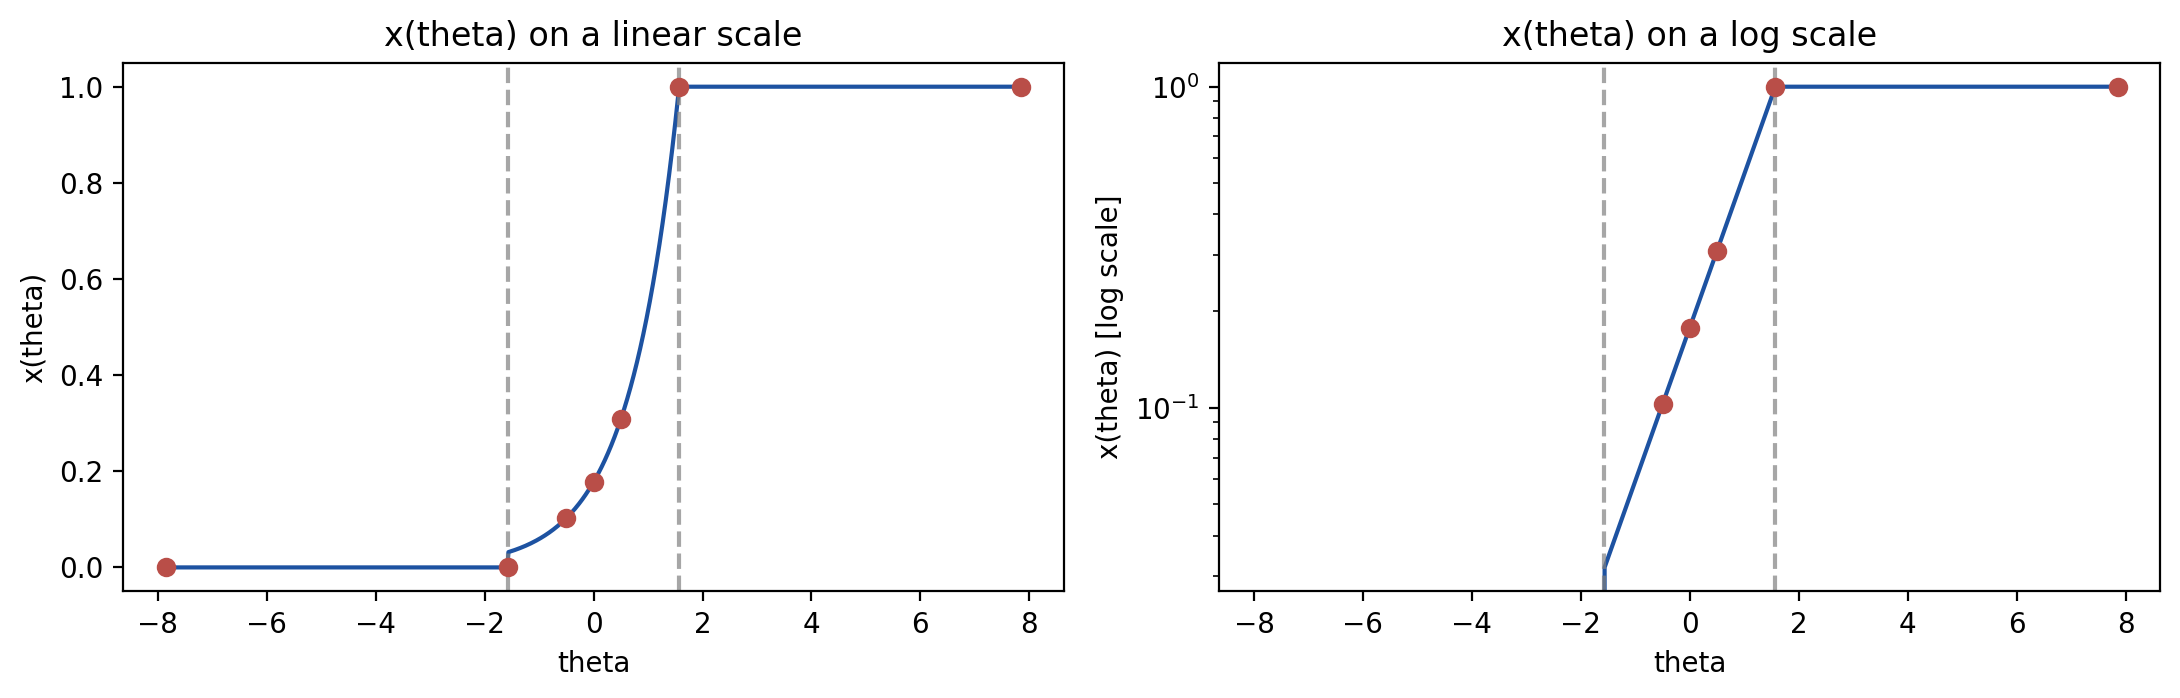

In [9]:
theta_map = np.linspace(base_model.theta_min, base_model.theta_max, 800)
x_map = np.asarray(base_model.pos_to_evidence(theta_map, base_model.gamma_E), dtype=float)
theta_min_impl = float(base_model.theta_min)
theta_max_impl = float(base_model.theta_max)
interval_impl = theta_max_impl - theta_min_impl
normalization_impl = 1.0 - np.exp(-float(base_model.gamma_E) * interval_impl)
log_linearized_map = 1.0 - normalization_impl * x_map / float(base_model.boundary)

theta_samples = np.array([
    base_model.theta_min,
    base_model.coding_theta_min,
    -0.5,
    0.0,
    0.5,
    base_model.coding_theta_max,
    base_model.theta_max,
], dtype=float)
x_samples = np.asarray(base_model.pos_to_evidence(theta_samples, base_model.gamma_E), dtype=float)
log_linearized_samples = 1.0 - normalization_impl * x_samples / float(base_model.boundary)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].plot(theta_map, x_map, color='#1d52a1')
ax[0].scatter(theta_samples, x_samples, color='#b94e48', zorder=3)
ax[0].axvline(base_model.coding_theta_min, color='grey', linestyle='--', alpha=0.7)
ax[0].axvline(base_model.coding_theta_max, color='grey', linestyle='--', alpha=0.7)
ax[0].set_xlabel('theta')
ax[0].set_ylabel('x(theta)')
ax[0].set_title('x(theta) on a linear scale')

ax[1].semilogy(theta_map, log_linearized_map, color='#1d52a1')
ax[1].scatter(theta_samples, log_linearized_samples, color='#b94e48', zorder=3)
ax[1].axvline(base_model.coding_theta_min, color='grey', linestyle='--', alpha=0.7)
ax[1].axvline(base_model.coding_theta_max, color='grey', linestyle='--', alpha=0.7)
ax[1].set_xlabel('theta')
ax[1].set_ylabel('1 - Z x(theta) / boundary [log scale]')
ax[1].set_title('Linearized normalized residual on a log scale')

plt.tight_layout()

{
    'coding_frac': float(base_model.coding_frac),
    'gamma_E': float(base_model.gamma_E),
    'x(theta_min)': float(x_samples[0]),
    'x(coding_theta_min)': float(x_samples[1]),
    'x(theta=-0.5)': float(x_samples[2]),
    'x(theta=0.0)': float(x_samples[3]),
    'x(theta=0.5)': float(x_samples[4]),
    'x(coding_theta_max)': float(x_samples[5]),
    'x(theta_max)': float(x_samples[6]),
}


## Step 1: measure the sustained-drive speed law $v_\theta(c_{BE})$

The fitting window is chosen after the onset of the constant drive. The goal is to estimate a nearly steady translation speed rather than the immediate transient right after `t_start`.


1024


(-2.685350717849371e-05, -2.886577927592425e-05, 0.006203692872077227)

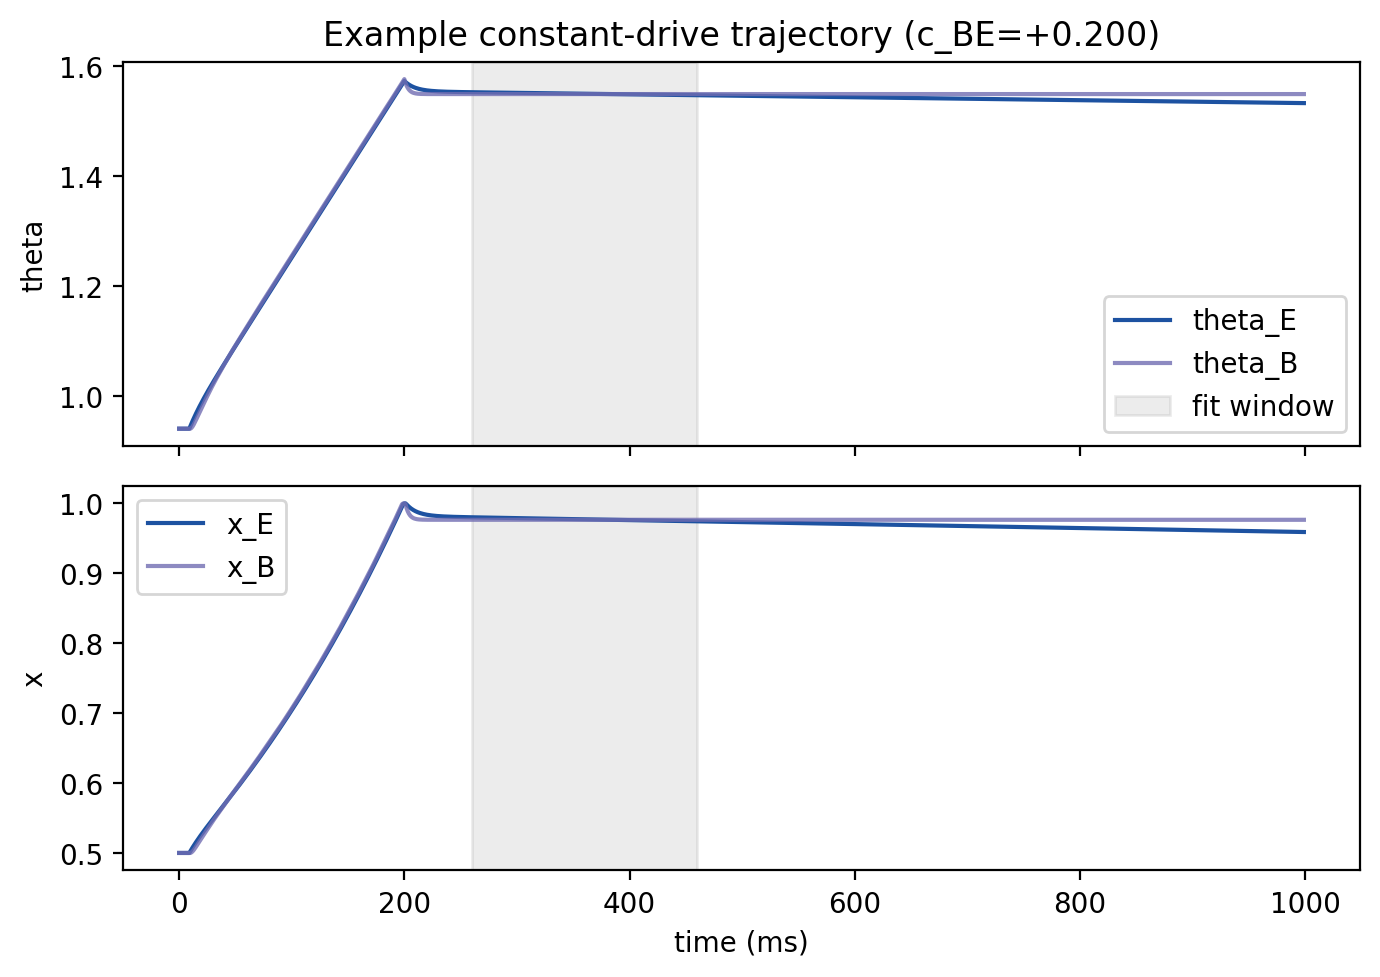

In [17]:
FIT_WINDOW = (260, 460)
C_BE_SWEEP = np.linspace(0, 0.3, 13)
EXAMPLE_C_BE = 0.2


def estimate_slope(times: np.ndarray, values: np.ndarray, window: tuple[int, int]) -> float:
    start, stop = window
    mask = (times >= start) & (times <= stop)
    if np.count_nonzero(mask) < 2:
        return float('nan')
    slope, _ = np.polyfit(times[mask], values[mask], deg=1)
    return float(slope)


def run_constant_drive_trial(c_be: float, *, x0: float = 0.5, fit_window: tuple[int, int] = FIT_WINDOW) -> dict:
    model = make_model(c_be=c_be, x0=x0)
    print(model.num_E)
    runner = model.run_simulation(
        mon_vars=['theta_E', 'theta_B', 'x_E', 'x_B', 'I_BE', 'I_EB', 'hit_boundary'],
        progress_bar=False,
        dt=1.0,
        get_RT=False,
    )

    times = np.arange(len(runner.mon.theta_E), dtype=float)
    theta_e = np.asarray(runner.mon.theta_E).reshape(-1)
    theta_b = np.asarray(runner.mon.theta_B).reshape(-1)
    x_e = np.asarray(runner.mon.x_E).reshape(-1)
    x_b = np.asarray(runner.mon.x_B).reshape(-1)
    hit = np.asarray(runner.mon.hit_boundary).reshape(-1)

    return {
        'c_BE': float(c_be),
        'times': times,
        'theta_E': theta_e,
        'theta_B': theta_b,
        'x_E': x_e,
        'x_B': x_b,
        'v_theta_E': estimate_slope(times, theta_e, fit_window),
        'v_theta_B': estimate_slope(times, theta_b, fit_window),
        'v_x_E': estimate_slope(times, x_e, fit_window),
        'v_x_B': estimate_slope(times, x_b, fit_window),
        'alignment_mean': float(np.mean(theta_b - theta_e)),
        'alignment_std': float(np.std(theta_b - theta_e)),
        'hit_boundary': bool(np.any(hit)),
        'fit_window': fit_window,
    }


example = run_constant_drive_trial(EXAMPLE_C_BE)

fig, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
ax[0].plot(example['times'], example['theta_E'], label='theta_E', color='#1d52a1')
ax[0].plot(example['times'], example['theta_B'], label='theta_B', color='#716db2', alpha=0.8)
ax[0].axvspan(*example['fit_window'], color='grey', alpha=0.15, label='fit window')
ax[0].set_ylabel('theta')
ax[0].legend(loc='best')
ax[0].set_title(f'Example constant-drive trajectory (c_BE={EXAMPLE_C_BE:+.3f})')

ax[1].plot(example['times'], example['x_E'], label='x_E', color='#1d52a1')
ax[1].plot(example['times'], example['x_B'], label='x_B', color='#716db2', alpha=0.8)
ax[1].axvspan(*example['fit_window'], color='grey', alpha=0.15)
ax[1].set_xlabel('time (ms)')
ax[1].set_ylabel('x')
ax[1].legend(loc='best')
plt.tight_layout()

example['v_theta_E'], example['v_x_E'], example['alignment_std']


In [ ]:
sweep_results = [run_constant_drive_trial(c_be) for c_be in C_BE_SWEEP]

c_be_vals = np.array([row['c_BE'] for row in sweep_results], dtype=float)
v_theta_vals = np.array([row['v_theta_E'] for row in sweep_results], dtype=float)
v_x_vals = np.array([row['v_x_E'] for row in sweep_results], dtype=float)
alignment_std_vals = np.array([row['alignment_std'] for row in sweep_results], dtype=float)
boundary_hits = np.array([row['hit_boundary'] for row in sweep_results], dtype=bool)

SMALL_SIGNAL_LIMIT = 0.08
small_signal_mask = np.abs(c_be_vals) <= SMALL_SIGNAL_LIMIT
gain_theta, intercept_theta = np.polyfit(c_be_vals[small_signal_mask], v_theta_vals[small_signal_mask], deg=1)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

ax[0].plot(c_be_vals, v_theta_vals, 'o-', color='#1d52a1', label='simulation')
ax[0].plot(
    c_be_vals,
    gain_theta * c_be_vals + intercept_theta,
    '--',
    color='black',
    label=f'small-signal fit: slope={gain_theta:.4g}'
)
ax[0].axvspan(-SMALL_SIGNAL_LIMIT, SMALL_SIGNAL_LIMIT, color='grey', alpha=0.12)
ax[0].set_xlabel('c_BE')
ax[0].set_ylabel('v_theta = d theta_E / dt')
ax[0].set_title('Step 1: v_theta(c_BE)')
ax[0].legend(loc='best')

ax[1].plot(c_be_vals, v_x_vals, 'o-', color='#716db2')
ax[1].set_xlabel('c_BE')
ax[1].set_ylabel('v_x = d x_E / dt')
ax[1].set_title('Induced latent-space speed')

ax[2].plot(c_be_vals, alignment_std_vals, 'o-', color='#b94e48')
ax[2].scatter(c_be_vals[boundary_hits], alignment_std_vals[boundary_hits], color='black', marker='x', label='boundary hit')
ax[2].set_xlabel('c_BE')
ax[2].set_ylabel('std(theta_B - theta_E)')
ax[2].set_title('Alignment stability diagnostic')
if np.any(boundary_hits):
    ax[2].legend(loc='best')

plt.tight_layout()

{
    'gain_theta_small_signal': float(gain_theta),
    'intercept_theta_small_signal': float(intercept_theta),
    'small_signal_limit': SMALL_SIGNAL_LIMIT,
}


## Step 2: derive a numerical $c_{BE}(\theta)$ for a desired constant $v_x$

Use the measured small-signal transfer law and the code-level evidence mapping $x(\theta)$ to build a numerical coupling profile. In the small-signal regime,

$$v_\theta \approx k_\theta c_{BE}$$

so a desired constant latent-space speed satisfies

$$v_x = \frac{dx}{d\theta} v_\theta \approx \frac{dx}{d\theta} k_\theta c_{BE}(\theta).$$

The notebook computes the required $c_{BE}(\theta)$ numerically from that relation.


In [ ]:
TARGET_VX = 1.0e-6
THETA_MARGIN = 0.02

theta_grid = np.linspace(base_model.coding_theta_min + THETA_MARGIN, base_model.coding_theta_max - THETA_MARGIN, 400)
x_grid = np.asarray(base_model.pos_to_evidence(theta_grid, base_model.gamma_E), dtype=float)
theta_min_impl = float(base_model.coding_theta_min)
theta_max_impl = float(base_model.coding_theta_max)
interval_impl = theta_max_impl - theta_min_impl
normalization_impl = 1.0 - np.exp(-float(base_model.gamma_E) * interval_impl)
dx_dtheta = (
    float(base_model.boundary)
    * float(base_model.gamma_E)
    * np.exp(-float(base_model.gamma_E) * (theta_grid - theta_min_impl))
    / normalization_impl
)

c_be_theta = TARGET_VX / (gain_theta * dx_dtheta)
predicted_v_theta = gain_theta * c_be_theta
predicted_v_x = predicted_v_theta * dx_dtheta

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))

ax[0].plot(theta_grid, x_grid, color='#1d52a1')
ax[0].set_xlabel('theta')
ax[0].set_ylabel('x(theta)')
ax[0].set_title('Code-level decision mapping')

ax[1].plot(theta_grid, c_be_theta, color='#716db2')
ax[1].set_xlabel('theta')
ax[1].set_ylabel('required c_BE(theta)')
ax[1].set_title('Derived coupling profile for constant v_x')

ax[2].plot(theta_grid, predicted_v_x, color='#b94e48', label='predicted v_x(theta)')
ax[2].axhline(TARGET_VX, color='black', linestyle='--', label='target v_x')
ax[2].set_xlabel('theta')
ax[2].set_ylabel('v_x')
ax[2].set_title('Consistency check')
ax[2].legend(loc='best')

plt.tight_layout()

{
    'target_v_x': TARGET_VX,
    'c_be_theta_min': float(np.min(c_be_theta)),
    'c_be_theta_max': float(np.max(c_be_theta)),
    'predicted_v_x_mean': float(np.mean(predicted_v_x)),
}


## Notes

- This notebook intentionally stops at the deterministic calibration agreed in discussion.
- Once the small-signal $v_\theta(c_{BE})$ law is trusted, the next step is to turn a stochastic amplitude process into diffusion in $\theta$ and then in $x$.
- If a supplementary translational-invariance figure is needed later, the clean follow-up is to restore position-specific preparation stimuli in a notebook-local runner and repeat the same speed measurement at several initial positions.
